In [24]:
# Code block 0.1

# Import some non-landlab libraries
import numpy as np
import matplotlib as mpl

# Import from the landlab library
from landlab import RasterModelGrid, imshow_grid, imshowhs_grid
from landlab.components import FastscapeEroder, FlowAccumulator, LinearDiffuser, ChannelProfiler
from landlab.plot.graph import plot_graph

In [25]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)

### Instantiate a grid

In [26]:
num_rows = 150  # number of grid rows
num_cols = 200  # number of grid columns
dxy = 10  # resolution of raster cell [m], or node horizontal and vertical spacing

# Create the grid
mg = RasterModelGrid((num_rows, num_cols), dxy)

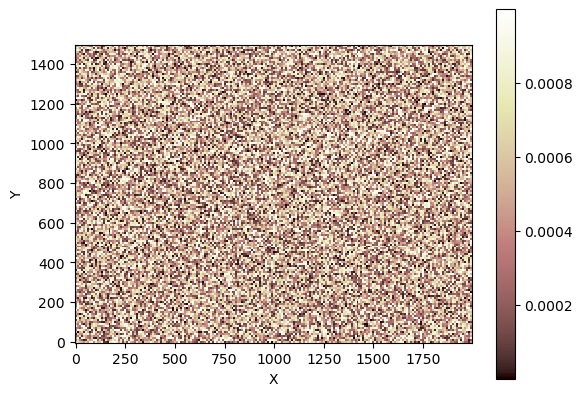

In [27]:
# Make some noise to add to the initial topography.
# This is not necessary, but it is a trick to make networks look more `real`

np.random.seed(0)  
mg_noise = np.random.rand(mg.number_of_nodes) / 1000.0  # intial noise on elevation grid

# Set-up the elevation field on the grid
zr = mg.add_zeros("topographic__elevation", at="node")
zr += mg_noise

# Plot the elevation map
imshow_grid(mg, "topographic__elevation")

### Set parameters and create an instance of the flow accumulation and fluvial erosion components

In [28]:
# Stream power parameters
K_sp = 1.0e-5  # erodibility, units depend on m and n exponents
m_sp = 0.5  # exponent on drainage area
n_sp = 1.0  # exponent on slope

# Create the flow accumulation and fluvial incision components
fr = FlowAccumulator(mg, flow_director="D8")
fs = FastscapeEroder(mg, m_sp=m_sp, n_sp=n_sp, K_sp=K_sp)

### Want to learn more about the FastscapeEroder parameters?

### Set model time and uplift parameters

In [29]:
dt = 1000  # time step [yr]
modeled_time = 0  # amount of time the landscape has evolved [yr]
time_to_run = 3e6  # time for the model loop to run [yr]

nsteps = int(time_to_run / dt)  # number of model time steps

uplift_rate = 0.00000001  # uplift rate [m/yr]
uplift_length = uplift_rate * dt # length of uplift per time step [m]

In [30]:
# close every edge
mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
outlet_node = 0
# reopen just that node as a fixed-value outlet
mg.status_at_node[outlet_node] = mg.BC_NODE_IS_FIXED_VALUE

### Run the fluvial model

In [31]:
for i in range(nsteps):
    zr[mg.core_nodes] += uplift_length  # uplift the landscape
    fr.run_one_step()  # route flow
    fs.run_one_step(dt)  # fluvial incision
    modeled_time += dt  # update time keeper
    
    # sometimes it's nice to see that the model is progressing, especially if it's slow
    if int(modeled_time % 1e5) == 0:
        print("model run time",modeled_time)
        print("maximum elevation",max(mg.at_node["topographic__elevation"][mg.core_nodes]))
        

model run time 100000
maximum elevation 0.0016938879715457035
model run time 200000
maximum elevation 0.0024510054363490537
model run time 300000
maximum elevation 0.0032782913350337204
model run time 400000
maximum elevation 0.004194915640764342
model run time 500000
maximum elevation 0.005131802837120492
model run time 600000
maximum elevation 0.006089715510618038
model run time 700000
maximum elevation 0.007064207010809022
model run time 800000
maximum elevation 0.008052217817831605
model run time 900000
maximum elevation 0.009037512714591061
model run time 1000000
maximum elevation 0.010024682098843715
model run time 1100000
maximum elevation 0.011017462476589914
model run time 1200000
maximum elevation 0.012012450209363012
model run time 1300000
maximum elevation 0.01300871874230942
model run time 1400000
maximum elevation 0.014006857426740418
model run time 1500000
maximum elevation 0.015005155257720618
model run time 1600000
maximum elevation 0.016003670529029346
model run time 

### Visualize the topography

##### Print all the Fields in the Grid

In [32]:
# mg.at_node.keys()

In [33]:
# mg.at_node["topographic__elevation"]

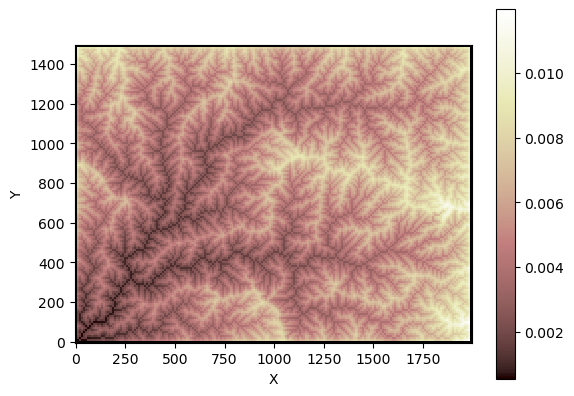

In [34]:
imshow_grid(mg, "topographic__elevation")

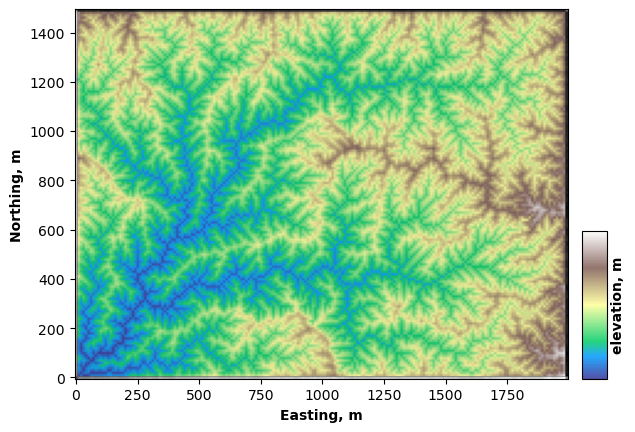

In [35]:
# Elevation map draped over shaded relief
# Don't get thrown off by all the parameter values.
# They are included because this function makes beautiful visualizations,
# and it can be helpful to `see` different aspects of the landscape by changing
# the parameters.

cmap = mpl.colormaps["terrain"]
plot_type = "Drape1"
#plot_type = "DEM"
drape1 = "topographic__elevation"
ax = imshowhs_grid(
    mg,
    "topographic__elevation",
    plot_type=plot_type,
    drape1=drape1,
    alpha=0.85,
#    altdeg=55.,
#    azdeg=180,
    cmap=cmap,
    grid_units=("m", "m"),
    default_fontsize=10,
    cbar_tick_size=10,
    var_name="elevation, m",
    cbar_width="100%",
    cbar_or="vertical",
    bbox_to_anchor=[1.03, 0.0, 0.05, 8],
    colorbar_label_y=3,
    #colorbar_label_x=-100,
    ticks_km=False,
)

### A drainage area map

Because drainage area varies by orders of magnitude, it is often easier to visualize on a log scale. Plotting drainage area is one way to visualize the networks. It is also helpful to see if the model has developed continuous networks.

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

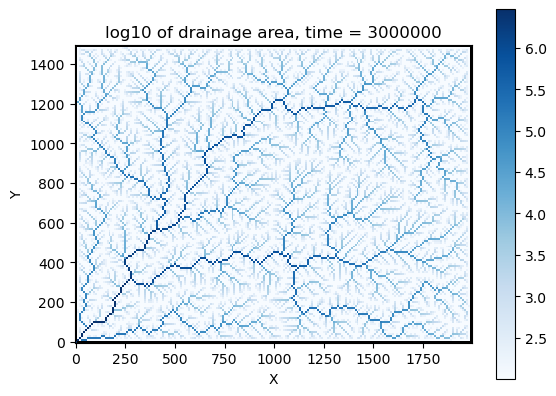

In [36]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

## Space Tryout Tutorial

In [179]:
import numpy as np
from landlab import RasterModelGrid
from landlab.components import (
    FlowAccumulator,
    DepressionFinderAndRouter,
    Space,
    FastscapeEroder,
)

In [145]:
# mg = RasterModelGrid((5, 5), xy_spacing=10.0)
# _ = mg.add_zeros("topographic__elevation", at="node")
# mg.at_node["topographic__elevation"] += (
#     mg.node_y / 10.0 + mg.node_x / 10.0 + np.random.rand(len(mg.node_y)) / 10.0)
# mg.set_closed_boundaries_at_grid_edges(bottom_is_closed=True,left_is_closed=True,right_is_closed=True,
# top_is_closed=True)
# mg.set_watershed_boundary_condition_outlet_id(
#     0, mg.at_node["topographic__elevation"], -9999.0)
# fsc_dt = 100.0
# space_dt = 100.0

In [146]:
# fr = FlowAccumulator(mg, flow_director="D8")
# df = DepressionFinderAndRouter(mg)
# fsc = FastscapeEroder(mg, K_sp=0.001, m_sp=0.5, n_sp=1)

In [147]:
# for _ in range(100):
#     fr.run_one_step()
#     df.map_depressions()
#     fsc.run_one_step(dt=fsc_dt)
#     mg.at_node["topographic__elevation"][0] -= 0.001  # Uplift

In [148]:
# imshow_grid(mg, "topographic__elevation")

#### Adding Soil to the Drainage Network

In [149]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

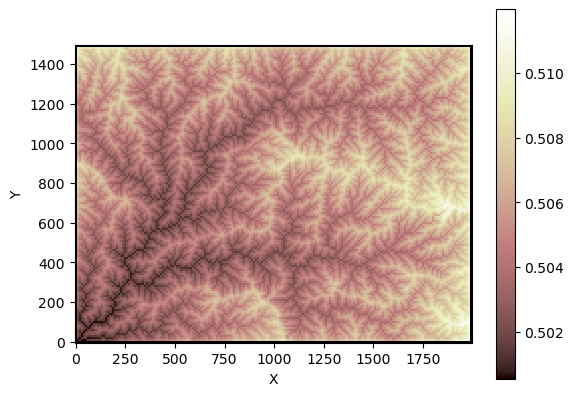

In [150]:
imshow_grid(mg, "topographic__elevation")

#### Space without Rainfall

In [151]:
ha = Space(
    mg,
    K_sed=0.001,
    K_br=0.000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [159]:
### This one takes 10 mins to run

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(366):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

model run completed for dt 0


KeyboardInterrupt: 

In [153]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([0.5, 0.5, 0.5, ..., 0.5, 0.5, 0.5], shape=(30000,))

In [154]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([0.501, 0.501, 0.501, ..., 0.501, 0.501, 0.501], shape=(30000,))

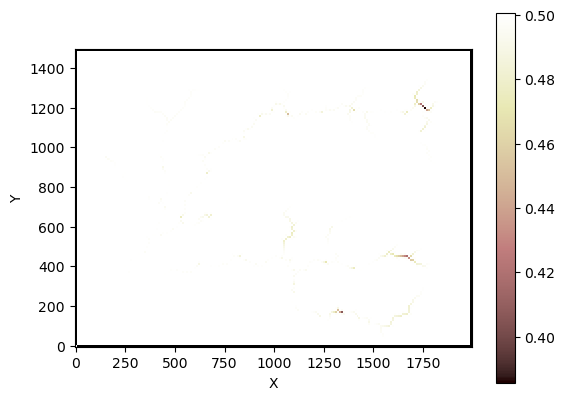

In [158]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

In [156]:
mg.at_node.keys()

['topographic__elevation',
 'water__unit_flux_in',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__sink_flag',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope',
 'soil__depth',
 'sediment__influx',
 'sediment__outflux',
 'sediment__flux',
 'bedrock__elevation',
 'depression__depth',
 'depression__outlet_node',
 'is_pit',
 'flood_status_code']

## Space with Single Rainfall as Runoff

In [17]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

FieldError: Unable to add the field, 'soil__depth', to the group, 'node', because a field with that name already exists in that group. Use `clobber=True` to replace the existing field. For example, grid.add_field('soil__depth', at='node', clobber=True)

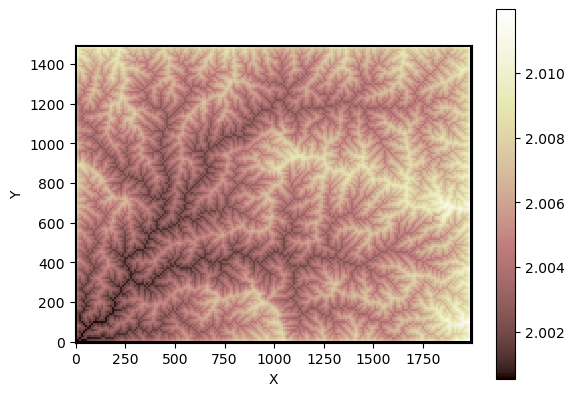

In [18]:
imshow_grid(mg, "topographic__elevation")

#### Space

In [19]:
ha = Space(
    mg,
    K_sed=0.0001,
    K_br=0.000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [20]:
### This one takes 10 mins to run

fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = 23.0)
df = DepressionFinderAndRouter(mg)

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(36):  # Space component loop
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 0
model run completed for dt 1
model run completed for dt 2
model run completed for dt 3
model run completed for dt 4
model run completed for dt 5
model run completed for dt 6
model run completed for dt 7
model run completed for dt 8
model run completed for dt 9
model run completed for dt 10
model run completed for dt 11
model run completed for dt 12
model run completed for dt 13
model run completed for dt 14
model run completed for dt 15
model run completed for dt 16
model run completed for dt 17
model run completed for dt 18
model run completed for dt 19
model run completed for dt 20
model run completed for dt 21
model run completed for dt 22
model run completed for dt 23
model run completed for dt 24
model run completed for dt 25
model run completed for dt 26
model run completed

In [21]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([2., 2., 2., ..., 2., 2., 2.], shape=(30000,))

In [22]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([2.001, 2.001, 2.001, ..., 2.001, 2.001, 2.001], shape=(30000,))

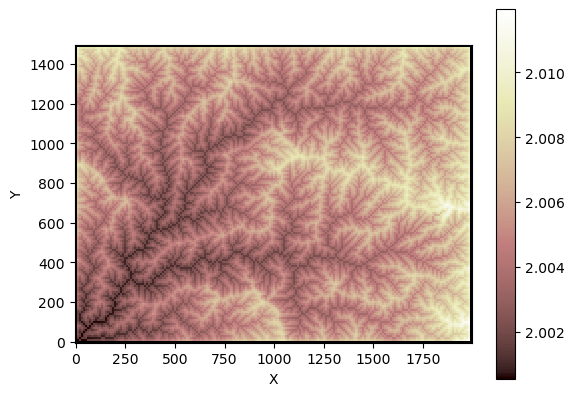

In [23]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

## Space with Variable Rainfall as Runoff

In [37]:
_ = mg.add_zeros("soil__depth", at="node", dtype=float)
mg.at_node["soil__depth"] += 2.0
mg.at_node["topographic__elevation"] += mg.at_node["soil__depth"]

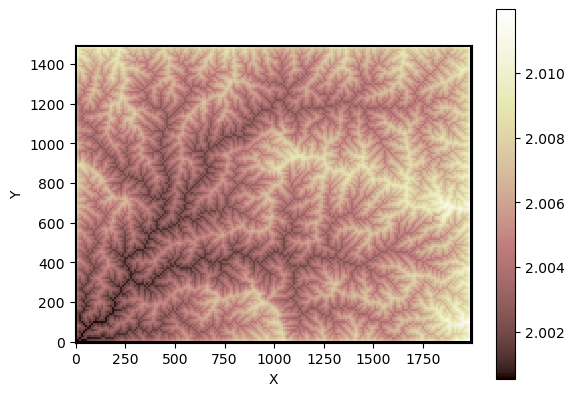

In [38]:
imshow_grid(mg, "topographic__elevation")

#### Space

In [49]:
ha = Space(
    mg,
    K_sed=0.0001,
    K_br=0.000000001,
    F_f=0.5,
    phi=0.1,
    H_star=1.0,
    v_s=0.001,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

In [79]:
runoff_array = np.random.rand(36)
len(runoff_array)
np.random.uniform(0, 5, 36).mean()
np.clip(np.random.normal(2, 0.5, 36), 0, None).mean()

np.float64(2.0586816040759803)

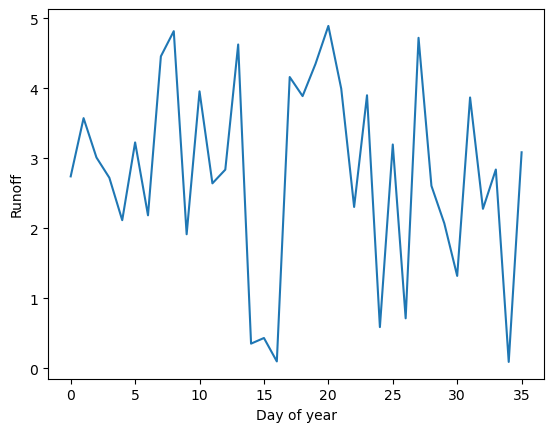

In [81]:
## Runoff timeseries
# runoff_array = np.narry(365 values)
# plot runoff_array

np.random.seed(0)
runoff_array = np.random.uniform(0, 5, 36)



import matplotlib.pyplot as plt
plt.plot(runoff_array)
plt.xlabel("Day of year")
plt.ylabel("Runoff")
plt.show()

In [82]:
### This one takes 10 mins to run

# fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = 23.0)
df = DepressionFinderAndRouter(mg)

fsc_dt = 100.0
space_dt = 1.0
df = DepressionFinderAndRouter(mg) 
for _ in range(36):  # Space component loop
    fr = FlowAccumulator(mg, flow_director="D8", runoff_rate = runoff_array[_])
    fr.run_one_step()
    df.map_depressions()
    ha.run_one_step(dt=space_dt)
    # mg.at_node["bedrock__elevation"][0] -= 2e-6 * space_dt
    print(f"model run completed for dt {_}")

FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 0
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 1
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 2
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE SUPPLIED RUNOFF_RATE!
model run completed for dt 3
FlowAccumulator found both the field 'water__unit_flux_in' and a provided float or array for the runoff_rate argument. THE FIELD IS BEING OVERWRITTEN WITH THE S

In [83]:
np.around(mg.at_node["soil__depth"], decimals=3)

array([2., 2., 2., ..., 2., 2., 2.], shape=(30000,))

In [84]:
np.around(mg.at_node["topographic__elevation"], decimals=3)

array([2.001, 2.001, 2.001, ..., 2.001, 2.001, 2.001], shape=(30000,))

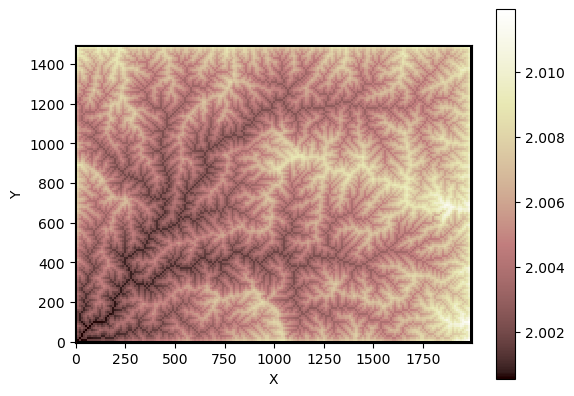

In [85]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "topographic__elevation")

Text(0.5, 1.0, 'log10 of drainage area, time = 3000000')

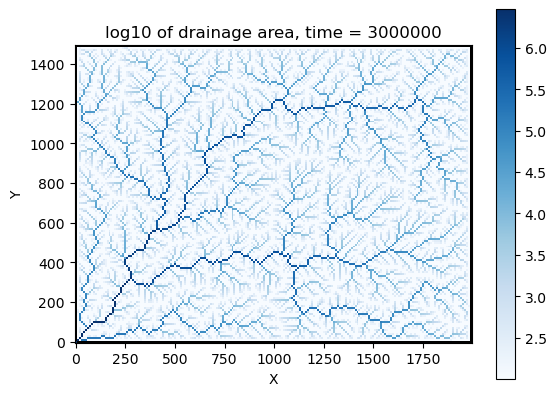

In [86]:
# calculate the log of drainage area array
log10area = np.log10(mg.at_node["drainage_area"] + 1.0)

# make the map
imshow_grid(mg, log10area, cmap="Blues")
title_text = f"log10 of drainage area, time = {modeled_time}"
mpl.pyplot.title(title_text)

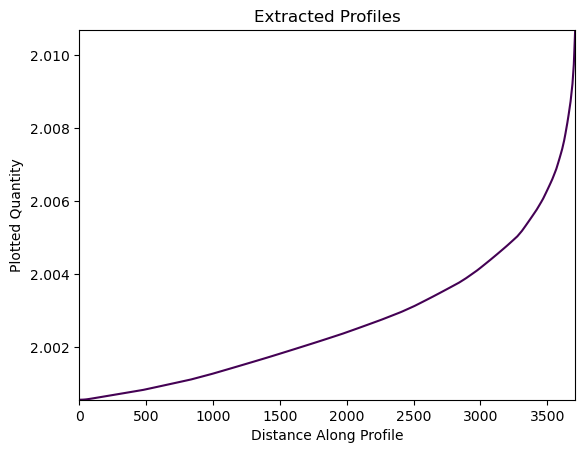

In [87]:
# Instantiate the ChannelProfiler component.
# The drainage area map can be helpful for deciding the minimum channel threshold.
prf = ChannelProfiler(mg, number_of_watersheds=1, minimum_channel_threshold=1e2)

# Run the component and plot the profiles
prf.run_one_step()
prf.plot_profiles()

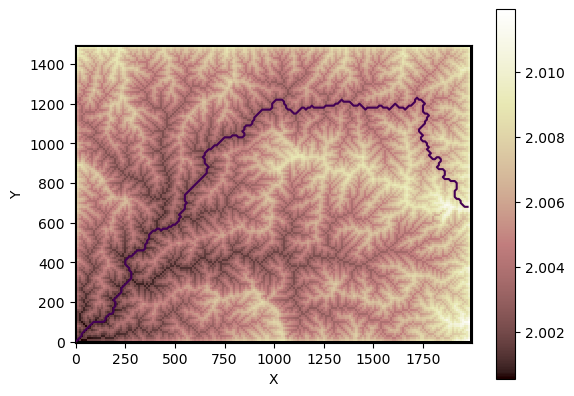

In [88]:
# Plot the channels on map
prf.plot_profiles_in_map_view()

In [89]:
mg.at_node.keys()

['topographic__elevation',
 'drainage_area',
 'flow__data_structure_delta',
 'flow__upstream_node_order',
 'surface_water__discharge',
 'flow__link_to_receiver_node',
 'flow__receiver_node',
 'topographic__steepest_slope',
 'soil__depth',
 'sediment__influx',
 'sediment__outflux',
 'sediment__flux',
 'bedrock__elevation',
 'depression__depth',
 'depression__outlet_node',
 'is_pit',
 'flood_status_code',
 'water__unit_flux_in',
 'flow__sink_flag']

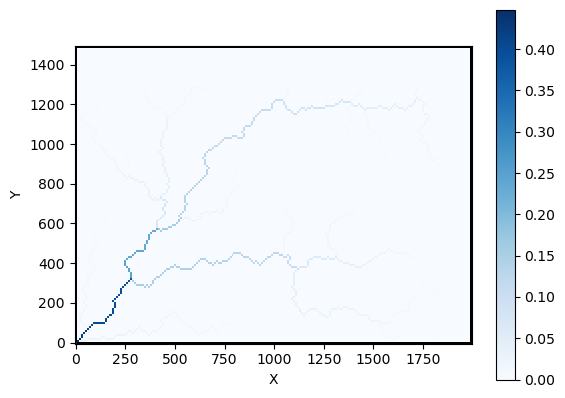

In [99]:
# imshow_grid(mg, "topographic__elevation")
imshow_grid(mg, "sediment__influx", cmap="Blues")

## Field Extraction at Specific Node

## Viz Ideas

- Rivers Water Level with Soil Level
- 1961 to 2014 ------ Resulted more than 20m Sediment Accumulation [Resulted in capactiy loss of the dam]
- 